#  S4:T3 Análisis de Sentimientos: Reviews de App Store

Se nos ha pedido analizar los sentimientos de las reviews de una aplicación en la App Store y responder un conjunto de preguntas.

1. ¿Tienen todas las apps la misma proporción de polaridad en sus reseña?
2. ¿Qué palabras parecen ser las que generan una mayor polaridad?
3. ¿Cómo de bueno es el modelo que se puede generar con este conjunto de datos? Podemos valorarlo con la comparación entre la proporción de clases en el dataset original y el accuracy del modelo
4. ¿Podemos hacer uso de Laplace smoothing para mejorar los resultados obtenidos?, ¿Cuánto mejora el modelo?
5. ¿Qué resultados obtenemos en el modelo?, ¿Predice correctamente?, ¿En todas las apps?, ¿Qué datos podrían ayudarnos a mejorar la predicción?

La estructura de los datos es la siguiente:

- `package_name`: Nombre de la app
- `review`: Texto del usuario con la review
- `polarity`: Sentimiento de polaridad de la review:
    - `1`: Review con un sentimiento muy positivo o muy negativo
    - `0`: Review con un sentimiento neutro

El presente notebook, se realizará en Python 3.12.

### 1. Carga de datos y análisis exploratorio incial

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')

SEED = 2026

In [2]:
# Load data in ../data/sentiment_dataset.csv
data = pd.read_csv('../data/sentiment_dataset.csv')

# Shape of the dataset
print(f"Dataset shape (rows, columns): {data.shape}")

Dataset shape (rows, columns): (891, 3)


In [3]:
# print head of the dataset
data.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [4]:
# Print summary statistics of the dataset
data.describe()

,polarity
count,891.000000
mean,0.344557
std,0.475490
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Como podemos ver existen 891 filas. Las variable es categorica, siendo 0 una review con un sentimiento muy positivo o muy negativo y 0 una review con un sentimiento neutro. No hay valores nulos, por tanto no existe trabajo adicional que realizar. 

In [5]:
# Print value counts
data.package_name.value_counts()

package_name
com.facebook.katana           40
com.linkedin.android          40
com.king.candycrushsaga       40
com.imangi.templerun2         40
com.supercell.clashofclans    40
com.viber.voip                40
com.facebook.orca             40
com.Slack                     40
com.dropbox.android           40
com.evernote                  40
com.uc.browser.en             40
com.opera.mini.native         40
org.mozilla.firefox           40
com.twitter.android           39
com.android.chrome            39
com.tencent.mm                39
com.google.android.talk       39
com.whatsapp                  39
com.hamrokeyboard             39
com.rovio.angrybirds          39
com.hamropatro                38
com.shirantech.kantipur       36
jabanaki.todo.todoly          24
Name: count, dtype: int64

Para cada app, parece ser que se ha recogido un numero simiular de reviews, por tanto tenemos un dataset balanceado en numero de reviews por app. Sin embargo, hay que explorar si esto esta balanceado sobre la variable de polaridad, es decir, si cada app tiene un número similar de reviews con polaridad 0 y 1. Podmeos empezar a responder las preguntas planteadas, que ayudarán a explorar la data y entendere que sucede.

## a. ¿Tienen todas las apps la misma proporción de polaridad en sus reseña?

In [6]:
# Groupby packege_name by polarity and count
data.groupby(['package_name', 'polarity']).size().unstack(fill_value=0)

polarity,0,1
package_name,,
com.Slack,11,29
com.android.chrome,34,5
com.dropbox.android,23,17
com.evernote,10,30
com.facebook.katana,40,0
com.facebook.orca,39,1
com.google.android.talk,36,3
com.hamrokeyboard,5,34
com.hamropatro,0,38


Ya podemos intuir que no existe la misma porporción de polaridad en cada app, vamos a verlo en un grafico de barras horizontales, será mas sencillo de visualizar.

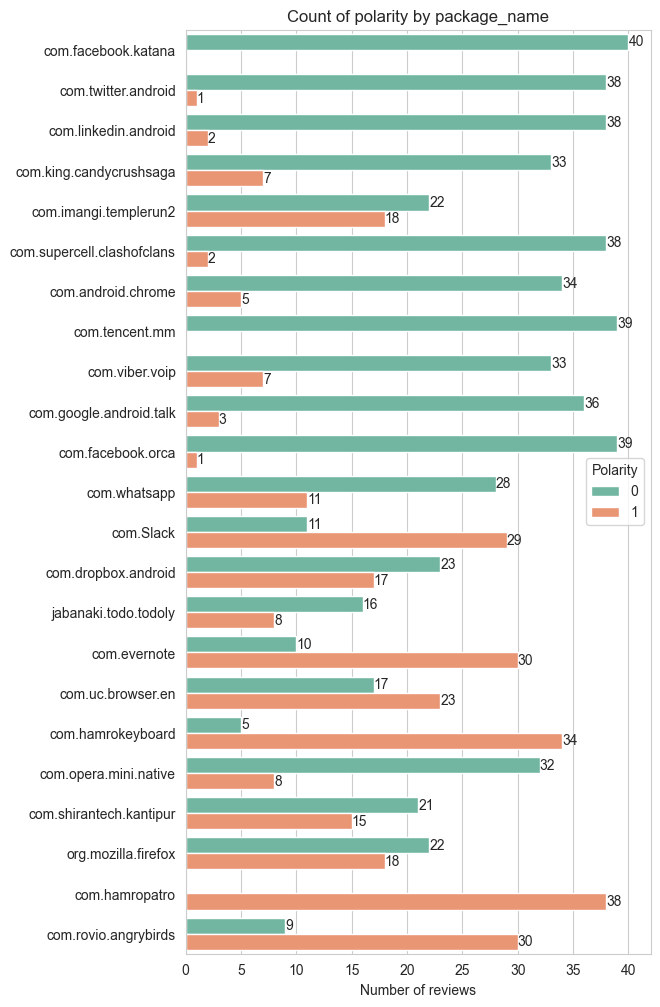

In [7]:
# With Seabonr
plt.figure(figsize=(6, 12))

sns.countplot(data=data, y='package_name', hue='polarity', palette='Set2')

# Set text label over bars
for container in plt.gca().containers:
    plt.bar_label(container)
plt.title('Count of polarity by package_name')
plt.xlabel('Number of reviews')
plt.ylabel('')
plt.legend(title='Polarity', loc='best')
plt.show()

Solo en los casos de `org.mozilla.firefox` y `com.imangi.templerun2` parecer haber una proporción similar de reviews tanto con polaridad 1 como 0 sin ser exactamente iguales, en el resto de apps, la desproporción es evidente, con cero reviews de polaridad 1 y 40 de polaridad 0 al igual que su caso contrario como `com.hamropatro`. Las reviews a nivel de polaridad no se encuentran balanceadas.

## b. ¿Qué palabras parecen ser las que generan una mayor polaridad?

Para responder a esta pregunta, vamos a utilizar la libreria de scikit-learn. Aquí podemos encontrar el modulo de `MultinomialNB` para el modelo de naive bayes y a su vez usar el `CountVectorizer` o `TfidVectorizer` para convertir el texto en una matriz de conteo o de TF-IDF respectivamente. En este caso, vamos a usar el `CountVectorizer` ya que es el que mas se parece a lo presentado durante la clase. 

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Divide the dataset into features and target variable and split into training and testing sets
from sklearn.model_selection import train_test_split

# Unicodedata for text processing
import unicodedata
import re

In [23]:
# Build a function to preprocess the text data
def preprocess_text(text):
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Copy dataframe
df = data.copy()

# Apply preprocessing function to the review column
df['review'] = df['review'].apply(preprocess_text)

# Divide the dataset into features and target variable
X = df.review
y = df.polarity

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Create instance of vectorizer
vectorizer = CountVectorizer(
    max_features= 500,
    stop_words= 'english',
    min_df= 2,
    max_df= 0.8
)

# Create Matrix
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Total Vocabulary
features_name = vectorizer.get_feature_names_out()
print(f"Total Vocabulary: {len(features_name)}")

Total Vocabulary: 500


In [20]:
# Fit Train Model with MultinomialNB
nb = MultinomialNB(alpha=1.0) # Laplace smoothing
nb.fit(X_train_vec, y_train)

# Extract feature importance by polarity
# for difference of log probabilities
log_prob_polary = nb.feature_log_prob_[1]
log_prob_neutro = nb.feature_log_prob_[0]
feature_importance = log_prob_polary - log_prob_neutro

# Get Ranking of features by importance
top_words_polarity_idx = np.argsort(feature_importance)[-20:][::-1]

# Get the top 20 words for polarity
top_words_polarity = features_name[top_words_polarity_idx]
print("Top 20 words for polarity:")
print(top_words_polarity)

Top 20 words for polarity:
['birds' 'hamro' 'angry' 'excellent' 'brilliant' 'žŕľ' 'nepali' 'żŕ'
 'type' 'ŕľ' 'şŕ' 'keyboard' 'šŕ' 'žŕ' 'loved' 'amazing' 'love' 'devices'
 'notes' 'best']
